## Import Libraries

In [4]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## Load the Train/Test Data

In [2]:
X_train = joblib.load("X_train.pkl")
X_test = joblib.load("X_test.pkl")

y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (12000, 23)
Testing Features  : (3000, 23)
Training Labels   : (12000,)
Testing Labels    : (3000,)


## Class Distribution

In [8]:
import numpy as np

# Count each class
classes, counts = np.unique(y_train, return_counts=True)

print("Class Distribution:")
for cls, count in zip(classes, counts):
    print(f"Class {cls}: {count}")

print("\nClass Percentage:")
for cls, count in zip(classes, counts):
    print(f"Class {cls}: {(count / len(y_train)) * 100:.2f}%")

Class Distribution:
Class 0: 9832
Class 1: 2168

Class Percentage:
Class 0: 81.93%
Class 1: 18.07%


## Calculate scale_pos_weight

In [9]:
# Count majority and minority class samples
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

# Calculate scale_pos_weight
scale_pos_weight = negative_count / positive_count

print(f"Approved Claims (Class 0): {negative_count}")
print(f"Denied Claims  (Class 1): {positive_count}")

print(f"\nCalculated scale_pos_weight: {scale_pos_weight:.2f}")

Approved Claims (Class 0): 9832
Denied Claims  (Class 1): 2168

Calculated scale_pos_weight: 4.54


## Build the Weighted XGBoost Model

In [11]:
# Train XGBoost with class weighting
weighted_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

weighted_model.fit(X_train, y_train)

print("✅ Weighted XGBoost model trained successfully.")

✅ Weighted XGBoost model trained successfully.


## Generate Predictions

In [12]:
# Generate predictions
y_pred_weighted = weighted_model.predict(X_test)

# Generate probability scores
y_prob_weighted = weighted_model.predict_proba(X_test)[:, 1]

print("✅ Predictions generated successfully.")
print("Number of predictions:", len(y_pred_weighted))

✅ Predictions generated successfully.
Number of predictions: 3000


## Evaluate the Weighted Model

In [13]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_weighted)
precision = precision_score(y_test, y_pred_weighted)
recall = recall_score(y_test, y_pred_weighted)
f1 = f1_score(y_test, y_pred_weighted)
roc_auc = roc_auc_score(y_test, y_prob_weighted)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.7203
Precision: 0.2683
Recall   : 0.3173
F1 Score : 0.2908
ROC-AUC  : 0.6135


## Weighted Model
Detects about 32% of future denials.

## Classification Report

In [14]:
# Classification Report
print("Classification Report:\n")

print(classification_report(y_test, y_pred_weighted))

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.81      0.83      2458
           1       0.27      0.32      0.29       542

    accuracy                           0.72      3000
   macro avg       0.56      0.56      0.56      3000
weighted avg       0.74      0.72      0.73      3000



## Confusion Matrix

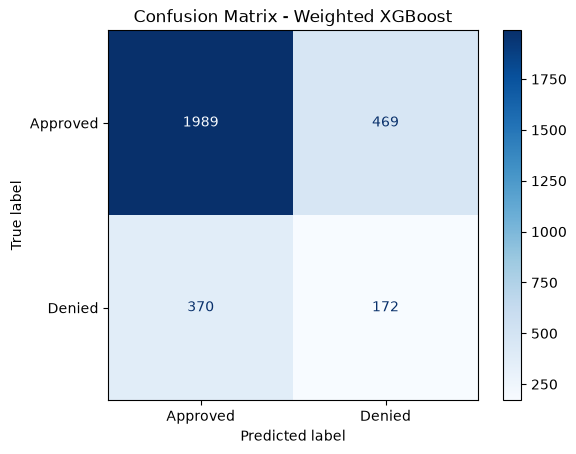

In [15]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_weighted)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Approved", "Denied"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Weighted XGBoost")
plt.show()

## Feature Importance

In [16]:
# Create feature importance DataFrame
feature_importance_weighted = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": weighted_model.feature_importances_
})

# Sort by importance
feature_importance_weighted = feature_importance_weighted.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 features
feature_importance_weighted.head(10)

,Feature,Importance
10,Prior_Auth_Obtained,0.119928
13,NCCI_Bundling_Flag,0.101646
11,Eligibility_Verified,0.081752
12,Duplicate_Claim_Flag,0.076913
14,Clearinghouse_Validation_Passed,0.066501
16,Provider_Payer_Prior_Denial_Count,0.064868
17,Chronic_Condition_Flag,0.034406
7,Billed_Amount,0.033319
22,Claim_Submission_Delay,0.030762
15,Provider_Monthly_Claim_Volume,0.030394


## Plot Feature Importance

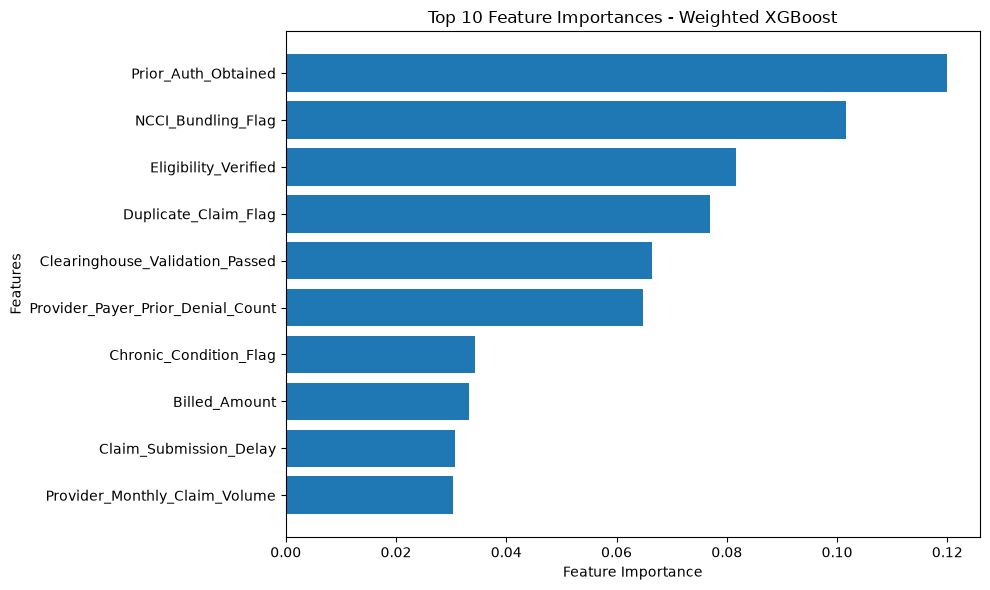

In [17]:
# Plot the top 10 important features
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_weighted["Feature"].head(10),
    feature_importance_weighted["Importance"].head(10)
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances - Weighted XGBoost")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [18]:
# Save the weighted model
joblib.dump(weighted_model, "weighted_xgboost_model.pkl")

print("✅ Weighted XGBoost model saved successfully.")

✅ Weighted XGBoost model saved successfully.


## Apply SMOTE

In [19]:
# Apply SMOTE only to the training data
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Training Shape:")
print(X_train.shape, y_train.shape)

print("\nAfter SMOTE:")
print(X_train_smote.shape, y_train_smote.shape)

Original Training Shape:
(12000, 23) (12000,)

After SMOTE:
(19664, 23) (19664,)


## Verify Class Distribution

In [20]:
import numpy as np

classes, counts = np.unique(y_train_smote, return_counts=True)

print("Class Distribution After SMOTE\n")

for cls, count in zip(classes, counts):
    print(f"Class {cls}: {count}")

Class Distribution After SMOTE

Class 0: 9832
Class 1: 9832


## Train XGBoost on SMOTE Data

In [21]:
# Train XGBoost on the SMOTE-balanced dataset
smote_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

print("✅ SMOTE XGBoost model trained successfully.")

✅ SMOTE XGBoost model trained successfully.


## Generate Predictions

In [22]:
# Generate predictions
y_pred_smote = smote_model.predict(X_test)

# Generate prediction probabilities
y_prob_smote = smote_model.predict_proba(X_test)[:, 1]

print("✅ Predictions generated successfully.")
print("Number of predictions:", len(y_pred_smote))

✅ Predictions generated successfully.
Number of predictions: 3000


## Evaluate the SMOTE Model

In [23]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_smote)
precision = precision_score(y_test, y_pred_smote)
recall = recall_score(y_test, y_pred_smote)
f1 = f1_score(y_test, y_pred_smote)
roc_auc = roc_auc_score(y_test, y_prob_smote)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.7600
Precision: 0.2682
Recall   : 0.1900
F1 Score : 0.2225
ROC-AUC  : 0.5817


## Classification Report

In [24]:
print("Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_smote
))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      2458
           1       0.27      0.19      0.22       542

    accuracy                           0.76      3000
   macro avg       0.55      0.54      0.54      3000
weighted avg       0.73      0.76      0.74      3000



## Confusion Matrix

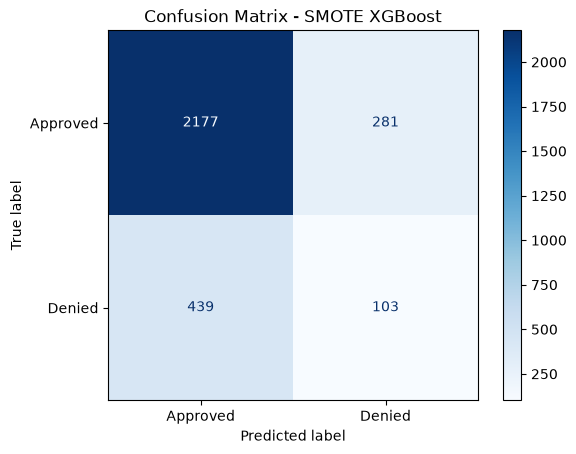

In [25]:
cm = confusion_matrix(y_test, y_pred_smote)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Approved", "Denied"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - SMOTE XGBoost")

plt.show()

| Metric       |   Baseline | Weighted XGBoost | SMOTE XGBoost |
| ------------ | ---------: | ---------------: | ------------: |
| Accuracy     | **80.37%** |           72.03% |        76.00% |
| Precision    | **36.09%** |           26.83% |        26.82% |
| **Recall**   |     11.25% |     **31.73%** ⭐ |        19.00% |
| **F1 Score** |     17.16% |     **29.08%** ⭐ |        22.25% |
| ROC-AUC      | **63.94%** |           61.35% |        58.17% |
